# 🧠 Section 07. Semantic Segmentation 이론
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- 분류·탐지·분할 태스크의 출력 형태를 비교하고 차이를 직접 확인한다
- Transposed Convolution과 Bilinear Upsample의 동작 방식과 차이를 실험으로 확인한다
- Encoder-Decoder 구조를 직접 구현하고 Skip Connection 유무에 따른 출력 차이를 비교한다
- IoU를 계산하고 세그멘테이션 성능이 어떻게 측정되는지 이해한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | 합성(Synthetic) Segmentation 데이터 |
| 크기 | NumPy 직접 생성 |
| 클래스 | 3개 (배경 0, 원형 1, 사각형 2) |
| 출처 | NumPy + random 직접 생성 |

## ⚙️ 실습 전 필수 확인 — 로컬 환경 설정

```bash
conda env create -f environment.yml
conda activate cnn-course
jupyter lab
```
> GPU가 있으면 자동으로 사용됩니다. CPU만 있어도 이번 실습은 충분합니다.

In [1]:
# ⚙️ 환경 설정 (반드시 가장 먼저 실행하세요)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 사용 디바이스: {device}")
print(f"✅ PyTorch 버전: {torch.__version__}")

✅ 사용 디바이스: cpu
✅ PyTorch 버전: 2.11.0+cpu


In [2]:
# ✅ 로컬 방식
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if nanum_fonts:
    font_path = nanum_fonts[0].fname          # 폰트 파일 경로 추출
    font_name = fm.FontProperties(fname=font_path).get_name()  # 실제 등록 이름 확인
    plt.rcParams['font.family'] = font_name
    print(f"✅ 적용 폰트: {font_name}")
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print("⚠️ 나눔 폰트 없음 → 맑은 고딕 적용")

plt.rcParams['axes.unicode_minus'] = False

⚠️ 나눔 폰트 없음 → 맑은 고딕 적용


## 📁 합성 Segmentation 데이터셋

실제 세그멘테이션 데이터셋(PASCAL VOC)은 수백 MB 다운로드가 필요합니다.  
이번 실습은 NumPy로 직접 만든 합성 데이터를 사용합니다.

| 클래스 | 의미 | 픽셀 비율(대략) |
|---|---|---|
| 0 | 배경 | ~60% |
| 1 | 원형 객체 | ~20% |
| 2 | 사각형 객체 | ~20% |

### 📖 왜 합성 데이터를 쓰는가?

> 💡 **핵심 직관**  
> 세그멘테이션의 핵심 개념(업샘플링, Skip Connection, IoU)은  
> 단순한 도형으로도 완전히 학습할 수 있습니다.  
> 복잡한 실제 이미지보다 단순한 도형에서 먼저 원리를 이해하고,  
> 나중에 실제 데이터로 넘어가는 것이 효율적입니다.

---
## 실습 1. 세 가지 비전 태스크 출력 비교

분류, 탐지, 분할이 **텐서 형태로 어떻게 다른지** 직접 확인합니다.  
같은 이미지에 대해 세 태스크의 출력이 어떻게 다른지 눈으로 보면 직관이 생깁니다.

### 📖 핵심 개념
| 태스크 | 출력 텐서 형태 | 예시 |
|---|---|---|
| 분류 | `(N, C)` — 클래스 점수 벡터 | `(1, 10)` |
| 탐지 | `[{'boxes':(M,4), 'labels':(M,)}]` — 박스 목록 | 가변 크기 |
| **분할** | `(N, C, H, W)` — **픽셀별 클래스 맵** | `(1, 3, 128, 128)` |

분할 모델은 입력과 **같은 공간 크기(H, W)** 의 출력을 내야 합니다.

In [3]:
# ─────────────────────────────────────────────
# 1-1. 세 태스크의 출력 텐서 형태 비교
# ─────────────────────────────────────────────
# 먼저 실행하며 각 출력 형태를 확인하세요

# 가상의 128×128 RGB 이미지 1장
dummy_image = torch.randn(1, 3, 128, 128)
print(f"입력 이미지 shape: {dummy_image.shape}  →  (배치, 채널, 높이, 너비)")

# 분류 모델 출력: 이미지 전체 → 클래스 1개
output_cls = torch.randn(1, 3)   # 3-class 분류
print(f"\n분류 출력 shape: {output_cls.shape}  →  (배치, 클래스 수)")
print(f"  예측 클래스: {output_cls.argmax(1).item()}")

# 분할 모델 출력: 픽셀 하나하나 → 각 픽셀의 클래스
output_seg = torch.randn(1, 3, 128, 128)  # 3-class 픽셀별 분류
print(f"\n분할 출력 shape: {output_seg.shape}  →  (배치, 클래스 수, 높이, 너비)")
print(f"  픽셀별 예측 클래스 shape: {output_seg.argmax(dim=1).shape}")
print(f"  총 예측해야 할 픽셀 수: {128 * 128:,}개")

입력 이미지 shape: torch.Size([1, 3, 128, 128])  →  (배치, 채널, 높이, 너비)

분류 출력 shape: torch.Size([1, 3])  →  (배치, 클래스 수)
  예측 클래스: 1

분할 출력 shape: torch.Size([1, 3, 128, 128])  →  (배치, 클래스 수, 높이, 너비)
  픽셀별 예측 클래스 shape: torch.Size([1, 128, 128])
  총 예측해야 할 픽셀 수: 16,384개


In [4]:
# ─────────────────────────────────────────────
# 1-2. 합성 데이터 생성 및 시각화 함수
# ─────────────────────────────────────────────

def generate_seg_sample(img_size=128, n_shapes=3, seed=None):
    """
    원형·사각형 도형이 있는 합성 세그멘테이션 샘플을 생성합니다.

    Returns:
        img  (np.ndarray): RGB 이미지 (H, W, 3), uint8
        mask (np.ndarray): 정답 마스크 (H, W), int64, 값: 0/1/2
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    img  = np.ones((img_size, img_size, 3), dtype=np.uint8) * 40  # 어두운 배경
    mask = np.zeros((img_size, img_size), dtype=np.int64)          # 배경 = 클래스 0

    for _ in range(n_shapes):
        shape = random.choice(['circle', 'rect'])
        cx, cy = np.random.randint(20, img_size-20, 2)
        r = np.random.randint(10, 28)
        color = tuple(np.random.randint(120, 255, 3).tolist())
        Y, X = np.ogrid[:img_size, :img_size]

        if shape == 'circle':
            region = (X-cx)**2 + (Y-cy)**2 < r**2
            img[region] = color
            mask[region] = 1   # 원형 = 클래스 1
        else:
            x1,y1 = max(0,cx-r), max(0,cy-r)
            x2,y2 = min(img_size,cx+r), min(img_size,cy+r)
            img[y1:y2, x1:x2] = color
            mask[y1:y2, x1:x2] = 2   # 사각형 = 클래스 2

    return img, mask

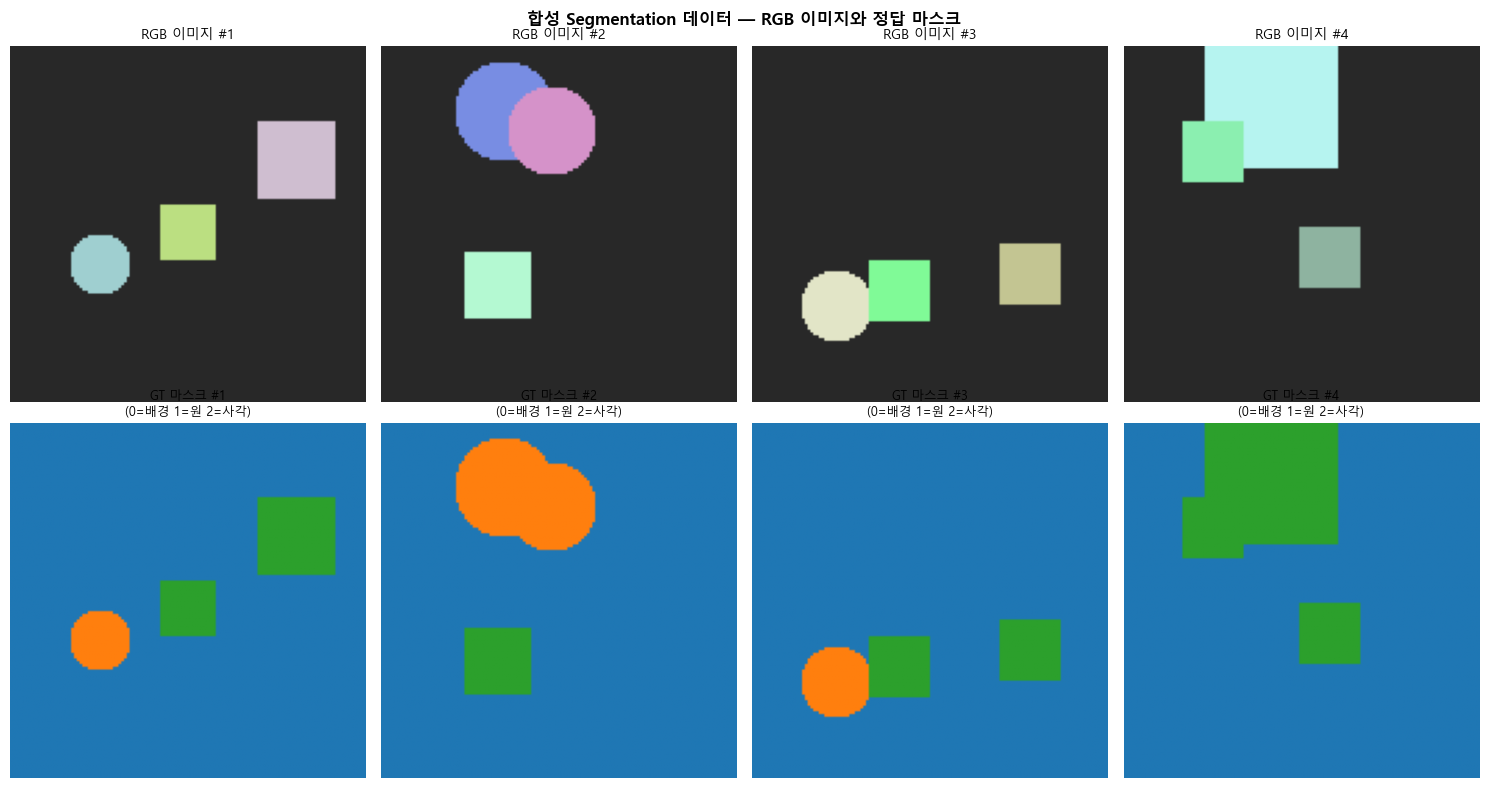

💡 분할 모델의 목표: RGB 이미지를 보고 오른쪽 마스크를 예측하는 것


In [5]:
# 샘플 4개 시각화
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
CLASS_COLORS = {0: '배경(검정)', 1: '원형(흰)', 2: '사각형(회색)'}

for col in range(4):
    img, mask = generate_seg_sample(seed=col*3)

    axes[0][col].imshow(img)
    axes[0][col].set_title(f"RGB 이미지 #{col+1}", fontsize=10)
    axes[0][col].axis('off')

    im = axes[1][col].imshow(mask, cmap='tab10', vmin=0, vmax=9)
    axes[1][col].set_title(f"GT 마스크 #{col+1}\n(0=배경 1=원 2=사각)", fontsize=9)
    axes[1][col].axis('off')

plt.suptitle("합성 Segmentation 데이터 — RGB 이미지와 정답 마스크", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 분할 모델의 목표: RGB 이미지를 보고 오른쪽 마스크를 예측하는 것")

---
## 실습 2. 업샘플링 방법 비교

세그멘테이션 모델은 Conv+Pool로 특징 맵을 **축소**한 뒤, 다시 원본 크기로 **복원**해야 합니다.  
이 "복원" 과정이 업샘플링입니다.

### 📖 왜 업샘플링이 필요한가?

```
입력 이미지 (128×128) 
→ Conv + Pool × 2  →  특징 맵 (32×32)   ← 1/4로 축소됨
→ 업샘플링 × 2    →  예측 맵 (128×128)  ← 원래 크기로 복원
```

축소된 상태로는 128×128 픽셀 하나하나에 클래스를 붙일 수 없습니다.  
반드시 업샘플링으로 원래 공간 크기를 되찾아야 합니다.

### 📖 두 가지 방법

| 방법 | 원리 | 특징 |
|---|---|---|
| Transposed Convolution | 학습 가능한 파라미터로 업샘플링 | 체커보드 아티팩트 위험 |
| Bilinear + Conv | 수학적 보간 + Conv로 정제 | 안정적, 실무 표준 |

먼저 두 방법을 실행해보고 결과를 눈으로 비교합니다.

In [6]:
# ─────────────────────────────────────────────
# 2-1. 두 업샘플링 방법 비교 — 먼저 실행해보세요
# ─────────────────────────────────────────────

# 다운샘플된 특징 맵을 가정 (실제 모델의 중간 출력)
x_small = torch.randn(1, 16, 8, 8)   # 원본의 1/4로 축소된 상태
print(f"입력 특징 맵: {x_small.shape}")

# ── 방법 1: Transposed Convolution ──
# kernel_size=2, stride=2 → 크기가 정확히 2배로 늘어남
transposed_conv = nn.ConvTranspose2d(
    in_channels=16, out_channels=16,
    kernel_size=2, stride=2     # stride=2 → 크기 2배
)

# ── 방법 2: Bilinear Interpolation + Conv ──
bilinear_up = nn.Sequential(
    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
    nn.Conv2d(16, 16, kernel_size=3, padding=1)
)

with torch.no_grad():
    out_tc = transposed_conv(x_small)
    out_bl = bilinear_up(x_small)

print(f"\n입력:                   {x_small.shape}")
print(f"Transposed Conv 출력:   {out_tc.shape}   ← 2배로 커짐")
print(f"Bilinear + Conv 출력:   {out_bl.shape}   ← 2배로 커짐")

tc_params = sum(p.numel() for p in transposed_conv.parameters())
bl_params = sum(p.numel() for p in bilinear_up.parameters())
print(f"\nTransposed Conv 파라미터: {tc_params:,}")
print(f"Bilinear + Conv 파라미터: {bl_params:,}")
print("\n💡 두 방법 모두 공간 크기를 2배로 키웁니다. 차이는 학습 방식입니다.")

입력 특징 맵: torch.Size([1, 16, 8, 8])

입력:                   torch.Size([1, 16, 8, 8])
Transposed Conv 출력:   torch.Size([1, 16, 16, 16])   ← 2배로 커짐
Bilinear + Conv 출력:   torch.Size([1, 16, 16, 16])   ← 2배로 커짐

Transposed Conv 파라미터: 1,040
Bilinear + Conv 파라미터: 2,320

💡 두 방법 모두 공간 크기를 2배로 키웁니다. 차이는 학습 방식입니다.


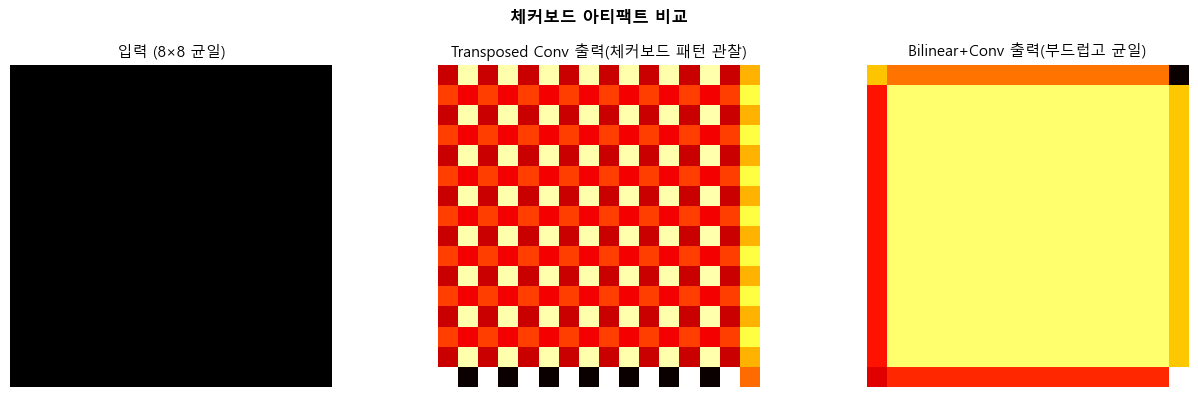

⚠️ Transposed Conv는 커널 크기와 stride 불일치 시 체커보드 패턴이 생깁니다.
   실무에서는 Bilinear + Conv 조합이 더 안정적입니다.


In [7]:
# ─────────────────────────────────────────────
# 2-2. 체커보드 아티팩트 시각화
# ─────────────────────────────────────────────
# Transposed Conv의 알려진 문제를 직접 확인합니다

# 강제로 아티팩트가 잘 보이도록 초기화 (실제 학습 후에는 줄어듦)
torch.manual_seed(7)
bad_tc = nn.ConvTranspose2d(1, 1, kernel_size=3, stride=2, padding=1, output_padding=1)
good_up = nn.Sequential(
    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
    nn.Conv2d(1, 1, 3, padding=1)
)

test_input = torch.ones(1, 1, 8, 8)
with torch.no_grad():
    out_bad  = bad_tc(test_input).squeeze().numpy()
    out_good = good_up(test_input).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(test_input.squeeze().numpy(), cmap='gray')
axes[0].set_title("입력 (8×8 균일)", fontsize=11)
axes[0].axis('off')

axes[1].imshow(out_bad, cmap='hot')
axes[1].set_title("Transposed Conv 출력(체커보드 패턴 관찰)", fontsize=11)
axes[1].axis('off')

axes[2].imshow(out_good, cmap='hot')
axes[2].set_title("Bilinear+Conv 출력(부드럽고 균일)", fontsize=11)
axes[2].axis('off')

plt.suptitle("체커보드 아티팩트 비교", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("⚠️ Transposed Conv는 커널 크기와 stride 불일치 시 체커보드 패턴이 생깁니다.")
print("   실무에서는 Bilinear + Conv 조합이 더 안정적입니다.")

---
## 실습 3. Skip Connection 유무에 따른 차이

Section 07 교안에서 배운 Skip Connection의 핵심 역할을 실험으로 확인합니다.

### 📖 왜 Skip Connection이 필요한가?

인코더가 풀링을 거치면서 공간 정보(경계선 위치 등)를 잃어버립니다.  
Skip Connection은 잃기 전의 정보를 디코더에 직접 전달합니다.

```
인코더 단계 1 (H×W)  ─── skip ──→ 디코더 단계 1 (+concat)
인코더 단계 2 (H/2)  ─── skip ──→ 디코더 단계 2 (+concat)
Bottleneck (H/4)
```

먼저 완성된 예시를 실행해서 skip connection이 실제로 어떤 역할을 하는지 확인합니다.

In [ ]:
# ─────────────────────────────────────────────
# 3-1. Skip Connection의 역할 — 완성된 예시 먼저 실행
# ─────────────────────────────────────────────

# Skip Connection이 없는 단순 Encoder-Decoder
class PlainEncoderDecoder(nn.Module):
    """Skip connection 없는 기본 Encoder-Decoder (비교용)."""
    def __init__(self, num_classes=3):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1), nn.ReLU(inplace=True))
        self.enc2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1), nn.ReLU(inplace=True))
        self.pool = nn.MaxPool2d(2)
        # Decoder
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(32,32,3,padding=1), nn.ReLU(inplace=True))
        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.head = nn.Conv2d(16, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)       # (B, 32, 128, 128)
        e2 = self.enc2(self.pool(e1))  # (B, 64, 64, 64)
        e3 = self.pool(e2)             # (B, 64, 32, 32)
        d1 = self.dec1(self.up1(e3))   # skip 없이 그냥 업샘플
        out = self.head(self.up2(d1))
        return out

# Skip Connection이 있는 Encoder-Decoder
class SkipEncoderDecoder(nn.Module):
    """Skip connection이 있는 Encoder-Decoder (U-Net 원리)."""
    def __init__(self, num_classes=3):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1), nn.ReLU(inplace=True))
        self.enc2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1), nn.ReLU(inplace=True))
        self.pool = nn.MaxPool2d(2)
        
        # Decoder: concat 때문에 in_channels가 늘어남
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        # 💡 수정된 부분: 입력 채널을 96으로 변경 (e2의 64 + up1의 32 = 96)
        self.dec1 = nn.Sequential(nn.Conv2d(96,32,3,padding=1), nn.ReLU(inplace=True))  
        
        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        # e1의 32 + up2의 16 = 48
        self.dec2 = nn.Sequential(nn.Conv2d(48,16,3,padding=1), nn.ReLU(inplace=True))  
        self.head = nn.Conv2d(16, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)              # (B, 32, 128, 128) ← skip으로 저장
        e2 = self.enc2(self.pool(e1))  # (B, 64, 64, 64)  ← skip으로 저장
        e3 = self.pool(e2)             # (B, 64, 32, 32)

        d1 = self.up1(e3)              # (B, 32, 64, 64)
        d1 = torch.cat([e2, d1], dim=1)  # skip! concat → (B, 96, 64, 64)
        d1 = self.dec1(d1)             # (B, 32, 64, 64)

        d2 = self.up2(d1)              # (B, 16, 128, 128)
        d2 = torch.cat([e1, d2], dim=1)  # skip! concat → (B, 48, 128, 128)
        d2 = self.dec2(d2)             # (B, 16, 128, 128)

        return self.head(d2)

# Forward pass 검증
dummy = torch.randn(2, 3, 128, 128)
plain = PlainEncoderDecoder()
skip  = SkipEncoderDecoder()

with torch.no_grad():
    out_plain = plain(dummy)
    out_skip  = skip(dummy)

print(f"입력: {dummy.shape}")
print(f"Skip 없는 모델 출력: {out_plain.shape}")
print(f"Skip 있는 모델 출력: {out_skip.shape}")
print("✅ 두 모델 모두 입력과 동일한 공간 크기(128×128) 출력")

입력: torch.Size([2, 3, 128, 128])
Skip 없는 모델 출력: torch.Size([2, 3, 128, 128])
Skip 있는 모델 출력: torch.Size([2, 3, 128, 128])
✅ 두 모델 모두 입력과 동일한 공간 크기(128×128) 출력


모델 학습 중...
✅ 학습 완료


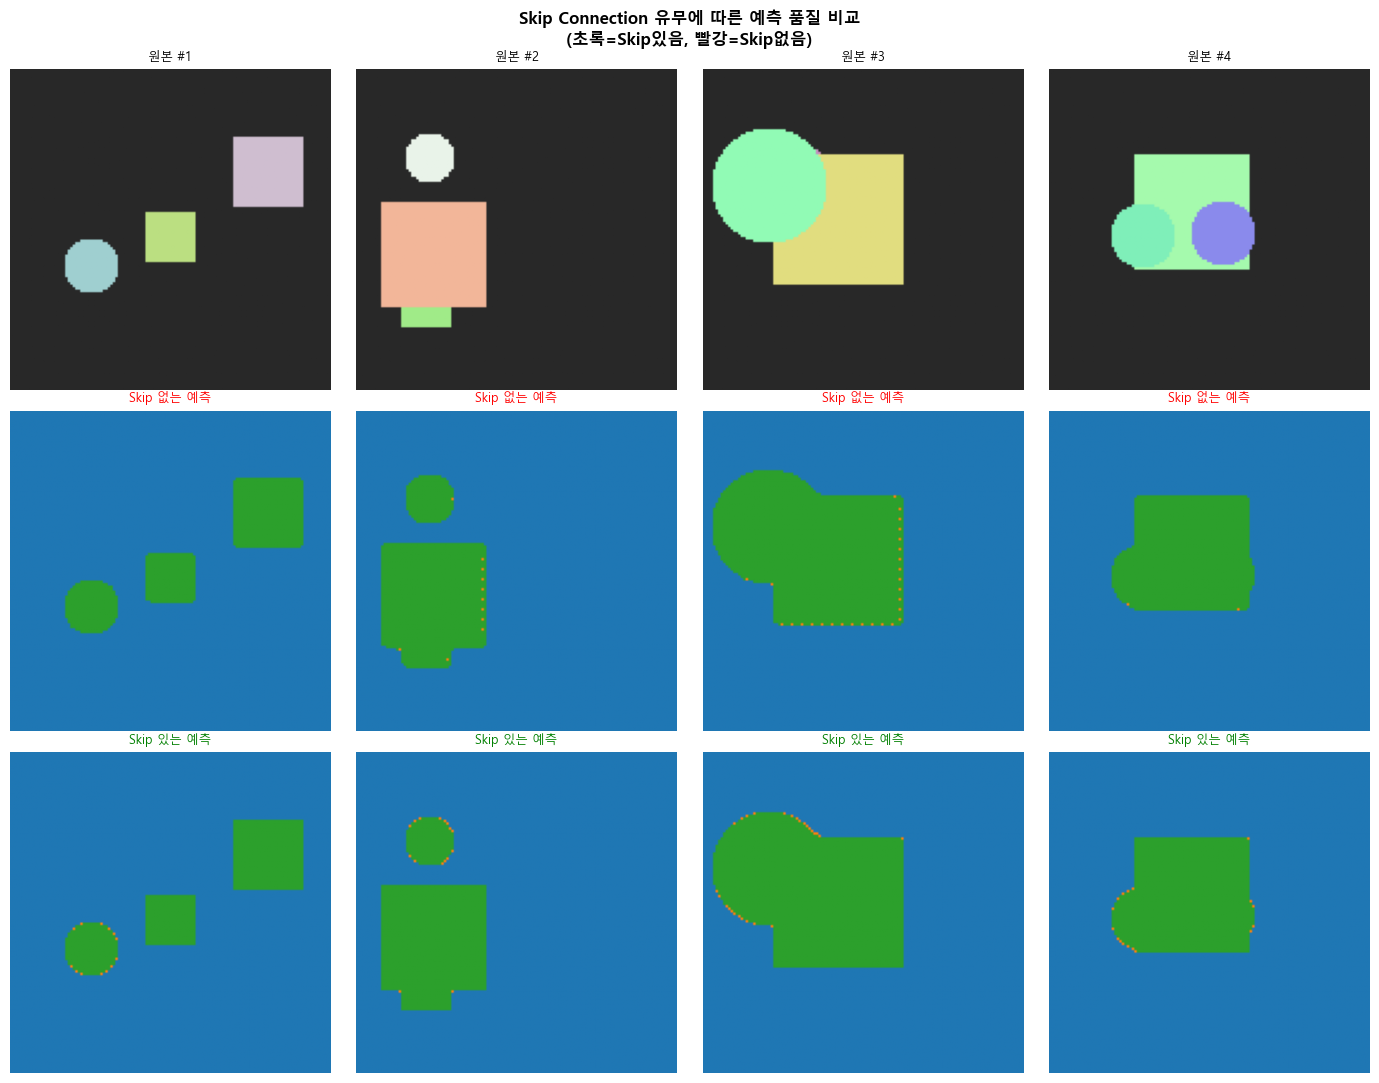

💡 Skip connection이 있을 때 경계선이 더 정밀하게 복원됩니다.


In [12]:
# ─────────────────────────────────────────────
# 3-2. 학습 후 경계선 복원 능력 비교
# ─────────────────────────────────────────────

# 간단한 데이터셋 클래스
class SyntheticSegDataset(Dataset):
    """합성 세그멘테이션 데이터셋."""
    def __init__(self, size=300, img_size=128):
        self.size = size; self.img_size = img_size
    def __len__(self): return self.size
    def __getitem__(self, idx):
        img, mask = generate_seg_sample(self.img_size, n_shapes=3, seed=idx)
        img_t  = torch.from_numpy(img).float().permute(2,0,1) / 255.0
        mask_t = torch.from_numpy(mask).long()
        return img_t, mask_t

train_ds = SyntheticSegDataset(300)
val_ds   = SyntheticSegDataset(60)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False)

def train_quick(model, epochs=8):
    """빠른 비교용 학습 (8 에포크)."""
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train()
        for imgs, masks in train_dl:
            opt.zero_grad()
            loss = crit(model(imgs), masks)
            loss.backward(); opt.step()
    return model

print("모델 학습 중...")
plain_trained = train_quick(PlainEncoderDecoder())
skip_trained  = train_quick(SkipEncoderDecoder())
print("✅ 학습 완료")

# 결과 시각화
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
plain_trained.eval(); skip_trained.eval()

with torch.no_grad():
    for col in range(4):
        img_t, mask_t = val_ds[col * 10]
        pred_plain = plain_trained(img_t.unsqueeze(0)).argmax(1).squeeze()
        pred_skip  = skip_trained(img_t.unsqueeze(0)).argmax(1).squeeze()

        axes[0][col].imshow(img_t.permute(1,2,0).clamp(0,1))
        axes[0][col].set_title(f"원본 #{col+1}", fontsize=9); axes[0][col].axis('off')

        axes[1][col].imshow(pred_plain.numpy(), cmap='tab10', vmin=0, vmax=9)
        axes[1][col].set_title("Skip 없는 예측", fontsize=9, color='red'); axes[1][col].axis('off')

        axes[2][col].imshow(pred_skip.numpy(), cmap='tab10', vmin=0, vmax=9)
        axes[2][col].set_title("Skip 있는 예측", fontsize=9, color='green'); axes[2][col].axis('off')

plt.suptitle("Skip Connection 유무에 따른 예측 품질 비교\n(초록=Skip있음, 빨강=Skip없음)", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print("💡 Skip connection이 있을 때 경계선이 더 정밀하게 복원됩니다.")

---
## 실습 4. SimpleFCN 직접 구현

실습 3에서 Skip connection의 효과를 눈으로 확인했습니다.  
이제 같은 구조를 **직접 구현**해봅시다.

### 📖 SimpleFCN 구조
```
입력 (B, 3, 128, 128)
→ Encoder: Conv×2 → Pool → Conv×2 → Pool
→ Decoder: Upsample → Conv → Upsample → Conv  
→ Head: 1×1 Conv → 클래스 맵 (B, num_classes, 128, 128)
```

아래 코드의 Decoder 부분에 업샘플링 레이어를 추가하면 됩니다.  
실습 2에서 배운 `nn.ConvTranspose2d` 또는 `nn.Upsample`을 활용하세요.

In [ ]:
# ─────────────────────────────────────────────
# 4-1. ✏️ TODO: SimpleFCN 디코더 완성
# ─────────────────────────────────────────────

class SimpleFCN(nn.Module):
    """
    간단한 Fully Convolutional Network.
    입력과 동일한 공간 크기(H, W)의 클래스 맵을 출력합니다.

    Args:
        in_channels (int): 입력 채널 수 (기본값: 3, RGB)
        num_classes (int): 분류 클래스 수
    """
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()

        # ── 인코더 (제공됨) ──
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),          nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2)   # (B,32,H,W) → (B,32,H/2,W/2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2)   # (B,64,H/2,W/2) → (B,64,H/4,W/4)

        # ── 디코더 (TODO) ──
        # 힌트: 크기를 2배로 복원하는 레이어가 2번 필요합니다.
        # ConvTranspose2d(64,32, kernel_size=2, stride=2) 또는
        # nn.Sequential(nn.Upsample(scale_factor=2,...), nn.Conv2d(...))

        self.up1 = ___   # (B,64,H/4,W/4) → (B,32,H/2,W/2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )

        self.up2 = ___   # (B,32,H/2,W/2) → (B,16,H,W)
        self.dec2 = nn.Sequential(
            nn.Conv2d(16,16,3,padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True)
        )

        self.head = nn.Conv2d(16, num_classes, kernel_size=1)   # 1×1 Conv → 클래스 맵

    def forward(self, x):
        """
        Args:
            x (Tensor): (B, C, H, W)
        Returns:
            Tensor: (B, num_classes, H, W) — 픽셀별 클래스 로짓
        """
        x = self.enc1(x)
        x = self.pool1(x)
        x = self.enc2(x)
        x = self.pool2(x)
        x = self.dec1(self.up1(x))
        x = self.dec2(self.up2(x))
        return self.head(x)

print("SimpleFCN 구현 후 다음 셀을 실행해 검증하세요!")

In [13]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
class SimpleFCN(nn.Module):
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32,32,3,padding=1),           nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.pool2 = nn.MaxPool2d(2)

        # 정답: ConvTranspose2d로 크기 2배 복원
        self.up1  = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.up2  = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(16,16,3,padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True))
        self.head = nn.Conv2d(16, num_classes, 1)

    def forward(self, x):
        x = self.enc1(x);    x = self.pool1(x)
        x = self.enc2(x);    x = self.pool2(x)
        x = self.dec1(self.up1(x))
        x = self.dec2(self.up2(x))
        return self.head(x)

print("✅ SimpleFCN 정답 로드!")

✅ SimpleFCN 정답 로드!


In [14]:
# ─────────────────────────────────────────────
# 4-2. Forward pass 검증 (반드시 실행!)
# ─────────────────────────────────────────────
# ⚠️ 학습 전 더미 입력으로 shape 불일치를 미리 잡아야 합니다!

model_fcn = SimpleFCN(in_channels=3, num_classes=3).to(device)
dummy = torch.randn(2, 3, 128, 128).to(device)

with torch.no_grad():
    out = model_fcn(dummy)

print(f"입력: {dummy.shape}")
print(f"출력: {out.shape}")
assert out.shape == (2, 3, 128, 128), f"❌ 출력 shape 불일치: {out.shape}"
print("✅ Forward pass 성공! 입력과 동일한 공간 크기 유지")
print(f"파라미터 수: {sum(p.numel() for p in model_fcn.parameters()):,}")

입력: torch.Size([2, 3, 128, 128])
출력: torch.Size([2, 3, 128, 128])
✅ Forward pass 성공! 입력과 동일한 공간 크기 유지
파라미터 수: 87,955


---
## 실습 5. IoU — 세그멘테이션 성능 측정

### 📖 왜 Pixel Accuracy 대신 IoU를 쓰는가?

Pixel Accuracy(전체 픽셀 중 맞은 비율)는 클래스 불균형에 취약합니다.

> 💡 **함정 예시**  
> 배경이 90%, 객체가 10%인 이미지에서  
> "모든 픽셀을 배경으로 예측"하면 Pixel Accuracy = **90%** 입니다.  
> 하지만 객체를 하나도 못 찾은 최악의 모델입니다.

IoU는 이 함정을 피합니다.  
"모두 배경 예측"이면 객체 클래스의 IoU = 0이 되어 mIoU가 낮게 나옵니다.

> ⚠️ **구현 주의**: 이미지에 특정 클래스가 없으면 IoU 분모(union)가 0이 됩니다.  
> 이 경우 `float('nan')`으로 처리하고, 평균 시 `np.nanmean()`을 사용합니다.

### 📖 IoU 공식
```
IoU = |예측 ∩ 정답| / |예측 ∪ 정답|  =  TP / (TP + FP + FN)
```

In [15]:
# ─────────────────────────────────────────────
# 5-1. IoU 계산 — 완성 예시 먼저 실행
# ─────────────────────────────────────────────

def compute_iou_example(pred_mask, gt_mask, class_idx):
    """
    특정 클래스에 대한 IoU를 계산합니다 (완성된 예시).

    Args:
        pred_mask  (Tensor): 예측 마스크 (H, W), 값 = 클래스 인덱스
        gt_mask    (Tensor): 정답 마스크 (H, W), 값 = 클래스 인덱스
        class_idx  (int): 계산할 클래스 인덱스

    Returns:
        float: 해당 클래스의 IoU
    """
    pred_c = (pred_mask == class_idx)   # 해당 클래스로 예측한 픽셀
    gt_c   = (gt_mask   == class_idx)   # 해당 클래스의 실제 픽셀

    intersection = (pred_c & gt_c).sum().item()   # TP
    union        = (pred_c | gt_c).sum().item()   # TP + FP + FN

    return intersection / union if union > 0 else float('nan')

# 이상적인 경우: 예측 = 정답 → IoU = 1.0
perfect_pred = torch.tensor([[0,0,1,1],
                              [0,0,1,1],
                              [2,2,0,0],
                              [2,2,0,0]])
gt = perfect_pred.clone()  # 동일한 마스크
iou = compute_iou_example(perfect_pred, gt, class_idx=1)
print(f"완벽한 예측의 클래스 1 IoU: {iou:.4f}  (1.0이어야 함)")

# 부분 겹침: 예측이 정답보다 넓음
partial_pred = torch.tensor([[0,1,1,1],
                              [0,1,1,1],
                              [2,2,0,0],
                              [2,2,0,0]])
iou_partial = compute_iou_example(partial_pred, gt, class_idx=1)
print(f"부분 겹침의 클래스 1 IoU: {iou_partial:.4f}  (0~1 사이)")

# 전혀 겹치지 않음 → IoU = 0
no_overlap = torch.zeros(4, 4, dtype=torch.long)
iou_zero = compute_iou_example(no_overlap, gt, class_idx=1)
print(f"전혀 안 겹칠 때 클래스 1 IoU: {iou_zero:.4f}  (0.0이어야 함)")

완벽한 예측의 클래스 1 IoU: 1.0000  (1.0이어야 함)
부분 겹침의 클래스 1 IoU: 0.6667  (0~1 사이)
전혀 안 겹칠 때 클래스 1 IoU: 0.0000  (0.0이어야 함)


In [ ]:
# ─────────────────────────────────────────────
# 5-2. ✏️ TODO: 전체 클래스 mIoU 계산 함수
# ─────────────────────────────────────────────
# 위의 compute_iou_example을 참고해서
# 모든 클래스의 IoU를 계산하고 평균(mIoU)을 반환하는 함수를 완성하세요.

def compute_miou(pred_mask, gt_mask, num_classes=3):
    """
    모든 클래스의 IoU를 계산하고 mIoU를 반환합니다.

    Args:
        pred_mask  (Tensor): 예측 마스크 (H, W)
        gt_mask    (Tensor): 정답 마스크 (H, W)
        num_classes (int): 클래스 수

    Returns:
        tuple: (mIoU, [클래스별 IoU 리스트])
    """
    ious = []
    for cls in range(num_classes):
        pred_c = (pred_mask == cls)
        gt_c   = (gt_mask   == cls)

        intersection = (___ & ___).sum().item()   # 힌트: 두 마스크의 AND 연산
        union        = (___ | ___).sum().item()   # 힌트: 두 마스크의 OR 연산

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(___ / ___)   # 힌트: intersection / union

    miou = np.nanmean(ious)   # nan인 클래스는 제외하고 평균
    return miou, ious

print("compute_miou()를 완성한 뒤 다음 셀을 실행하세요!")

In [16]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
def compute_miou(pred_mask, gt_mask, num_classes=3):
    """모든 클래스의 IoU 계산 후 mIoU 반환."""
    ious = []
    for cls in range(num_classes):
        pred_c = (pred_mask == cls)
        gt_c   = (gt_mask   == cls)
        intersection = (pred_c & gt_c).sum().item()
        union        = (pred_c | gt_c).sum().item()
        ious.append(intersection / union if union > 0 else float('nan'))
    return np.nanmean(ious), ious

print("✅ compute_miou 정답 로드!")

✅ compute_miou 정답 로드!


In [17]:
# ─────────────────────────────────────────────
# 5-3. FCN 학습 + mIoU 평가
# ─────────────────────────────────────────────
# ⚠️ 세그멘테이션 loss도 CrossEntropyLoss를 사용합니다.
# 입력 형태만 다릅니다: logit (B,C,H,W) / target (B,H,W) long tensor

criterion_seg = nn.CrossEntropyLoss()
optimizer_fcn = optim.Adam(model_fcn.parameters(), lr=1e-3)
scheduler_fcn = optim.lr_scheduler.CosineAnnealingLR(optimizer_fcn, T_max=15)

hist = {"loss": [], "miou": []}
print(f"{'Epoch':>6} {'Loss':>10} {'mIoU':>10}")
print("-" * 30)

for epoch in range(1, 16):
    model_fcn.train()
    total_loss = 0
    for imgs, masks in train_dl:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer_fcn.zero_grad()
        loss = criterion_seg(model_fcn(imgs), masks)   # (B,C,H,W) vs (B,H,W)
        loss.backward(); optimizer_fcn.step()
        total_loss += loss.item()
    scheduler_fcn.step()

    # 검증
    model_fcn.eval()
    all_miou = []
    with torch.no_grad():
        for imgs, masks in val_dl:
            preds = model_fcn(imgs.to(device)).argmax(1).cpu()
            for p, g in zip(preds, masks):
                miou_val, _ = compute_miou(p, g)
                all_miou.append(miou_val)

    avg_loss = total_loss / len(train_dl)
    avg_miou = np.nanmean(all_miou)
    hist["loss"].append(avg_loss); hist["miou"].append(avg_miou)
    if epoch % 3 == 0:
        print(f"{epoch:>6} {avg_loss:>10.4f} {avg_miou:>10.4f}")

print("\n✅ 학습 완료!")

 Epoch       Loss       mIoU
------------------------------
     3     0.3730     0.6408
     6     0.1577     0.7894
     9     0.1130     0.7445
    12     0.0926     0.8018
    15     0.0889     0.8078

✅ 학습 완료!


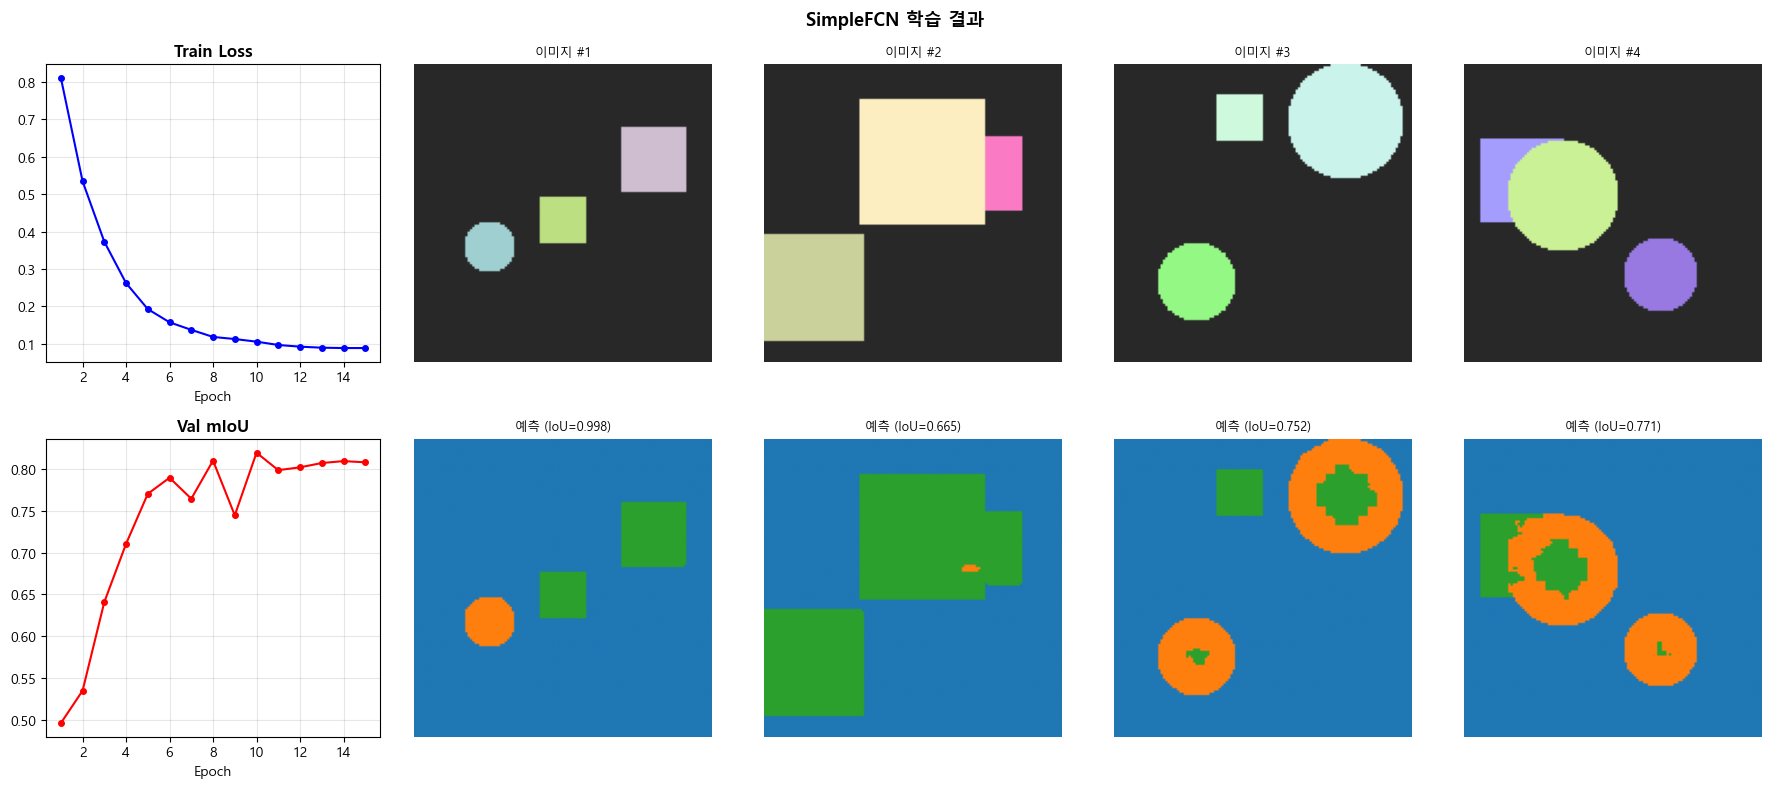

최종 Val mIoU: 0.8078


In [18]:
# ─────────────────────────────────────────────
# 5-4. 학습 결과 시각화
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
epochs_r = range(1, 16)

# 학습 곡선
ax_loss = axes[0][0]
ax_loss.plot(epochs_r, hist["loss"], 'b-o', markersize=4)
ax_loss.set_title("Train Loss", fontweight='bold')
ax_loss.set_xlabel("Epoch"); ax_loss.grid(alpha=0.3)

ax_miou = axes[1][0]
ax_miou.plot(epochs_r, hist["miou"], 'r-o', markersize=4)
ax_miou.set_title("Val mIoU", fontweight='bold')
ax_miou.set_xlabel("Epoch"); ax_miou.grid(alpha=0.3)

# 예측 결과
model_fcn.eval()
with torch.no_grad():
    for col in range(1, 5):
        img_t, mask_t = val_ds[(col-1) * 12]
        pred = model_fcn(img_t.unsqueeze(0).to(device)).argmax(1).squeeze().cpu()
        miou_val, _ = compute_miou(pred, mask_t)

        axes[0][col].imshow(img_t.permute(1,2,0).clamp(0,1))
        axes[0][col].set_title(f"이미지 #{col}", fontsize=9); axes[0][col].axis('off')

        axes[1][col].imshow(pred.numpy(), cmap='tab10', vmin=0, vmax=9)
        axes[1][col].set_title(f"예측 (IoU={miou_val:.3f})", fontsize=9); axes[1][col].axis('off')

plt.suptitle("SimpleFCN 학습 결과", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"최종 Val mIoU: {hist['miou'][-1]:.4f}")

---
## 🚀 도전 과제

### 과제 1. Skip Connection 추가
지금 만든 `SimpleFCN`에 Skip Connection(encoder→decoder concat)을 추가해  
`SkipFCN`을 만들고 mIoU 향상을 확인하세요.

```python
class SkipFCN(nn.Module):
    def forward(self, x):
        e1 = self.enc1(x)      # skip으로 저장
        ...
        d1 = torch.cat([e1, self.up1(...)], dim=1)  # concat!
        ...
```

### 과제 2. 클래스별 IoU 분석
`compute_miou`에서 반환하는 클래스별 IoU를 활용해  
배경·원형·사각형 각 클래스의 IoU를 막대 그래프로 시각화하세요.

### 과제 3. Pixel Accuracy 추가
```python
def pixel_accuracy(pred, gt):
    return (pred == gt).float().mean().item()
```
mIoU와 Pixel Accuracy를 함께 추적하고 차이를 분석하세요.
